In [6]:
import time 
import warnings
import numpy as np 
import pandas as pd
import requests
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader 
from sklearn.linear_model import Ridge

In [7]:
import requests, pandas as pd, time

url = "https://api.binance.com/api/v3/klines"

all_rows = []
current = int(pd.to_datetime("2017-08-17", utc=True).timestamp() * 1000)
end_ms  = int(pd.to_datetime("2026-09-29", utc=True).timestamp() * 1000)

while current < end_ms:
    res = requests.get(url, params={
        "symbol": "BTCUSDT", "interval": "1h",
        "startTime": current, "endTime": end_ms, "limit": 1000
    }).json()

    all_rows.extend(res)
    current = res[-1][0] + 1
    time.sleep(0.03)
    print(f"fetched {len(all_rows)} rows")

print(f"\nTotal: {len(all_rows)} rows")
print(all_rows[0])

fetched 1000 rows
fetched 2000 rows
fetched 3000 rows
fetched 4000 rows
fetched 5000 rows
fetched 6000 rows
fetched 7000 rows
fetched 8000 rows
fetched 9000 rows
fetched 10000 rows
fetched 11000 rows
fetched 12000 rows
fetched 13000 rows
fetched 14000 rows
fetched 15000 rows
fetched 16000 rows
fetched 17000 rows
fetched 18000 rows
fetched 19000 rows
fetched 20000 rows
fetched 21000 rows
fetched 22000 rows
fetched 23000 rows
fetched 24000 rows
fetched 25000 rows
fetched 26000 rows
fetched 27000 rows
fetched 28000 rows
fetched 29000 rows
fetched 30000 rows
fetched 31000 rows
fetched 32000 rows
fetched 33000 rows
fetched 34000 rows
fetched 35000 rows
fetched 36000 rows
fetched 37000 rows
fetched 38000 rows
fetched 39000 rows
fetched 40000 rows
fetched 41000 rows
fetched 42000 rows
fetched 43000 rows
fetched 44000 rows
fetched 45000 rows
fetched 46000 rows
fetched 47000 rows
fetched 48000 rows
fetched 49000 rows
fetched 50000 rows
fetched 51000 rows
fetched 52000 rows
fetched 53000 rows
fe

In [8]:
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
]
df = pd.DataFrame(all_rows, columns=columns)
print(df.head())

       open_time           open           high            low          close  \
0  1502942400000  4261.48000000  4313.62000000  4261.32000000  4308.83000000   
1  1502946000000  4308.83000000  4328.69000000  4291.37000000  4315.32000000   
2  1502949600000  4330.29000000  4345.45000000  4309.37000000  4324.35000000   
3  1502953200000  4316.62000000  4349.99000000  4287.41000000  4349.99000000   
4  1502956800000  4333.32000000  4377.85000000  4333.32000000  4360.69000000   

        volume     close_time quote_asset_volume  number_of_trades  \
0  47.18100900  1502945999999    202366.13839304               171   
1  23.23491600  1502949599999    100304.82356749               102   
2   7.22969100  1502953199999     31282.31266989                36   
3   4.44324900  1502956799999     19241.05829986                25   
4   0.97280700  1502960399999      4239.50358563                28   

  taker_buy_base_asset_volume taker_buy_quote_asset_volume ignore  
0                 35.16050300 

In [9]:
df = df.drop(columns = ["ignore"])

In [10]:
print(df.head())

       open_time           open           high            low          close  \
0  1502942400000  4261.48000000  4313.62000000  4261.32000000  4308.83000000   
1  1502946000000  4308.83000000  4328.69000000  4291.37000000  4315.32000000   
2  1502949600000  4330.29000000  4345.45000000  4309.37000000  4324.35000000   
3  1502953200000  4316.62000000  4349.99000000  4287.41000000  4349.99000000   
4  1502956800000  4333.32000000  4377.85000000  4333.32000000  4360.69000000   

        volume     close_time quote_asset_volume  number_of_trades  \
0  47.18100900  1502945999999    202366.13839304               171   
1  23.23491600  1502949599999    100304.82356749               102   
2   7.22969100  1502953199999     31282.31266989                36   
3   4.44324900  1502956799999     19241.05829986                25   
4   0.97280700  1502960399999      4239.50358563                28   

  taker_buy_base_asset_volume taker_buy_quote_asset_volume  
0                 35.16050300        

In [11]:
df["timetamp"] = pd.to_datetime(df["open_time"] , unit="ms" , utc=True )

for c in [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
]: 
    df[c] = df[c].astype(float)

In [12]:
df = df.sort_values("timetamp").drop_duplicates("timetamp").reset_index(drop=True) 



In [13]:
print(df.columns.tolist())

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'timetamp']


In [14]:
print(df[["volume", "quote_asset_volume"]].describe())
print(f"Mean price implied: {(df['quote_asset_volume'] / df['volume']).mean():.0f}")

print(df["number_of_trades"].describe())

violations = (df["taker_buy_base_asset_volume"] > df["volume"] * 1.001).sum()
print(f"Violations: {violations}")   

df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
print(df["taker_buy_ratio"].describe())

              volume  quote_asset_volume
count   79789.000000        7.978900e+04
mean     2458.483431        7.221173e+07
std      3798.804562        1.004060e+08
min         0.000000        0.000000e+00
25%       691.802800        1.444957e+07
50%      1312.636120        3.922556e+07
75%      2577.840400        9.109349e+07
max    137207.188600        3.005634e+09
Mean price implied: 38974
count    7.978900e+04
mean     8.422865e+04
std      1.124776e+05
min      0.000000e+00
25%      1.743400e+04
50%      4.463000e+04
75%      1.029870e+05
max      3.520247e+06
Name: number_of_trades, dtype: float64
Violations: 0
count    79789.000000
mean         0.495239
std          0.069289
min          0.000000
25%          0.460291
50%          0.496335
75%          0.531524
max          1.000000
Name: taker_buy_ratio, dtype: float64


In [15]:
df["return"] = ((df["close"]-df["open"] )/df["open"] )*100

In [16]:
df["hourly_range"] = (df["high"] - df["low"]) / df["low"] * 100

In [17]:

df["rt_cc"] = ((df["close"] - df["close"].shift(1)) / df["close"].shift(1)) * 100

In [18]:
df["range_ma_24"] = df["hourly_range"].rolling(24).mean()
df["range_ma_168"] = df["hourly_range"].rolling(168).mean()

In [19]:
df["volatility_24"] = df["rt_cc"].rolling(24).std()

In [20]:
df["volume_ma_24"] = df["volume"].rolling(24).mean()
df["volume_ratio"] = df["volume"] / (df["volume_ma_24"] + 1e-8)

In [21]:
tau = 2 * np.pi

hour = df["timetamp"].dt.hour
dow = df["timetamp"].dt.dayofweek

df[["hour_sin", "hour_cos"]] = np.column_stack(
    [np.sin(tau * hour / 24), np.cos(tau * hour / 24)]
)

df[["dow_sin", "dow_cos"]] = np.column_stack(
    [np.sin(tau * dow / 7), np.cos(tau * dow / 7)]
)

In [22]:
df["volume_change"] = df["volume"].pct_change() * 100

df["range_ma_720"] = df["hourly_range"].rolling(720).mean()
df["volatility_168"] = df["rt_cc"].rolling(168).std()

df["ma_24_price"]  = df["close"].rolling(24).mean()
df["ma_168_price"] = df["close"].rolling(168).mean()
df["distance_ma_24"]  = (df["close"] - df["ma_24_price"])  / (df["ma_24_price"]  + 1e-8)
df["distance_ma_168"] = (df["close"] - df["ma_168_price"]) / (df["ma_168_price"] + 1e-8)

for lag in (1, 2, 3, 6, 12):
    df[f"range_lag_{lag}"] = df["hourly_range"].shift(lag)

df["is_weekend"] = (df["timetamp"].dt.dayofweek >= 5).astype(float)

In [23]:
df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
df["order_flow_imbalance"] = (
    (2 * df["taker_buy_base_asset_volume"] - df["volume"])
    / (df["volume"] + 1e-8)
)
df["avg_trade_size"]     = df["volume"] / (df["number_of_trades"] + 1e-8)
df["avg_trade_size_usd"] = df["quote_asset_volume"] / (df["number_of_trades"] + 1e-8)

In [24]:
df["vol_regime"]      = df["volatility_24"] / (df["volatility_168"] + 1e-8)
df["range_vs_ma_168"] = df["hourly_range"] / (df["range_ma_168"] + 1e-8)
df["range_vs_ma_720"] = df["hourly_range"] / (df["range_ma_720"] + 1e-8)

df["high_vol_streak"] = (
    (df["hourly_range"] > df["range_ma_24"]).rolling(6).sum()
)

df["roll_max_720"]  = df["close"].rolling(720).max()
df["drawdown_720"]  = (df["close"] - df["roll_max_720"]) / (df["roll_max_720"] + 1e-8)

df["return_skew_168"] = df["rt_cc"].rolling(168).skew()

In [25]:
df["trade_count_change"] = df["number_of_trades"].pct_change() * 100

In [26]:
df["vwap_hour"]     = df["quote_asset_volume"] / (df["volume"] + 1e-8)
df["close_vs_vwap"] = (df["close"] - df["vwap_hour"]) / (df["vwap_hour"] + 1e-8) * 100

In [27]:
df["ofi_ma_24"]        = df["order_flow_imbalance"].rolling(24).mean()
df["ofi_std_24"]       = df["order_flow_imbalance"].rolling(24).std()
df["taker_buy_ma_24"]  = df["taker_buy_ratio"].rolling(24).mean()
df["trade_size_ma_24"] = df["avg_trade_size"].rolling(24).mean()
df["trade_size_ratio"] = df["avg_trade_size"] / (df["trade_size_ma_24"] + 1e-8)

In [28]:
for lag in (1, 2, 3):
    df[f"trade_ratio_lag_{lag}"] = df["taker_buy_ratio"].shift(lag)

In [29]:
for lag in (1, 2, 3, 6, 12):
    df[f"ofi_lag_{lag}"] = df["order_flow_imbalance"].shift(lag)

In [30]:
df["next_hour_range"] = df["hourly_range"].shift(-1)

In [31]:
df["target"] = df["next_hour_range"] / (df["range_ma_24"] + 1e-8)
df["target"] = df["target"].clip(0, 100)

In [32]:
def fetch_funding(start_ms, end_ms):
    records, cur_time = [], start_ms
    while cur_time < end_ms:
        res = requests.get("https://fapi.binance.com/fapi/v1/fundingRate",
                           params={"symbol": "BTCUSDT",
                                   "startTime": cur_time, "limit": 1000},
                           timeout=10)
        data = res.json()
        if not data:
            break
        records.extend(data)
        cur_time = data[-1]["fundingTime"] + 1
        time.sleep(0.02)

    df_f = pd.DataFrame(records)
    df_f["timestamp"] = pd.to_datetime(df_f["fundingTime"], unit="ms", utc=True)
    df_f["funding_rate"] = df_f["fundingRate"].astype(float)
    df_f["funding_rate_change"] = df_f["funding_rate"].diff()
    mean_8h = df_f["funding_rate"].rolling(21, min_periods=7).mean()
    std_8h  = df_f["funding_rate"].rolling(21, min_periods=7).std() + 1e-8
    df_f["z_funding"] = (df_f["funding_rate"] - mean_8h) / std_8h
    return df_f[["timestamp", "funding_rate", "funding_rate_change", "z_funding"]]

start_ms = int(df["timetamp"].min().timestamp() * 1000)
end_ms   = int(df["timetamp"].max().timestamp() * 1000)
df_funding = fetch_funding(start_ms, end_ms)

df = pd.merge_asof(df.sort_values("timetamp"),
                   df_funding.sort_values("timestamp"),
                   left_on="timetamp", right_on="timestamp",
                   direction="backward")

df[["funding_rate", "funding_rate_change", "z_funding"]] = (
    df[["funding_rate", "funding_rate_change", "z_funding"]].ffill().fillna(0)
)


In [33]:
cols_ohlcv = [
    "return",              
    "hourly_range",       
    "rt_cc",            
    "volume_change",       
    "volume_ratio",    
    "range_ma_24",
    "range_ma_168",
    "range_ma_720",
    "volatility_24",
    "volatility_168",
    "distance_ma_24",
    "distance_ma_168",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "is_weekend",
    "range_lag_1", "range_lag_2", "range_lag_3",
    "range_lag_6", "range_lag_12",
    "vol_regime",
    "range_vs_ma_168",
    "range_vs_ma_720",
    "high_vol_streak",
    "drawdown_720",
    "return_skew_168",
]
cols_orderflow = [
    "taker_buy_ratio",         
    "order_flow_imbalance",   
    "close_vs_vwap",          
    "avg_trade_size",         
    "avg_trade_size_usd",     
    "trade_size_ratio",       
    "trade_count_change", 
    "ofi_ma_24",
    "ofi_std_24",
    "taker_buy_ma_24",
    "trade_size_ma_24",
    "ofi_lag_1", "ofi_lag_2", "ofi_lag_3", "ofi_lag_6", "ofi_lag_12",
    "trade_ratio_lag_1", "trade_ratio_lag_2", "trade_ratio_lag_3",
]

cols_funding = ["funding_rate", "funding_rate_change", "z_funding"]

feature_cols = cols_ohlcv + cols_orderflow + cols_funding

In [34]:
needed = feature_cols + ["target"]

df_clean = df.replace([np.inf, -np.inf], np.nan)

df_clean = df_clean.dropna(subset=needed).reset_index(drop=True)

print("Total rows:", len(df_clean))
print("Features:", len(feature_cols))
print("First date:", df_clean["timetamp"].min())
print("Last date: ", df_clean["timetamp"].max())

Total rows: 79066
Features: 50
First date: 2017-09-16 09:00:00+00:00
Last date:  2026-09-28 23:00:00+00:00


In [35]:
split_point = int(len(df_clean) * 0.8)

x = df_clean[feature_cols].values.astype("float32")
y = df_clean["target"].values.astype("float32")  

x_train = x[:split_point]
x_test  = x[split_point:]
y_train = y[:split_point]
y_test  = y[split_point:]

In [36]:
mean = x_train.mean(axis=0)

std = x_train.std(axis=0) + 1e-8

x_train = (x_train - mean) / std

x_test = (x_test - mean) / std

y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

print("X_train shape:", x_train.shape)
print("X_test shape: ", x_test.shape)


X_train shape: (63252, 50)
X_test shape:  (15814, 50)


In [37]:
model = nn.Sequential(
    nn.Linear(len(feature_cols), 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)


print(model)

Sequential(
  (0): Linear(in_features=50, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)


In [38]:
x_t = torch.tensor(x_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

loader = DataLoader(TensorDataset(x_t, y_t), batch_size=128, shuffle=True)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [39]:
for epoch in range(30):
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()       
        preds = model(xb)            
        loss = loss_fn(preds, yb)    
        loss.backward()             
        optimizer.step()       

        total_loss += loss.item()

    avg = total_loss / len(loader)
    print("epoch", epoch + 1, "| loss", round(avg, 5))

epoch 1 | loss 0.6514
epoch 2 | loss 0.53807
epoch 3 | loss 0.52984
epoch 4 | loss 0.52629
epoch 5 | loss 0.52109
epoch 6 | loss 0.51966
epoch 7 | loss 0.51855
epoch 8 | loss 0.5177
epoch 9 | loss 0.51586
epoch 10 | loss 0.51662
epoch 11 | loss 0.51404
epoch 12 | loss 0.51453
epoch 13 | loss 0.5136
epoch 14 | loss 0.51298
epoch 15 | loss 0.5123
epoch 16 | loss 0.51158
epoch 17 | loss 0.51275
epoch 18 | loss 0.51081
epoch 19 | loss 0.51316
epoch 20 | loss 0.50972
epoch 21 | loss 0.51313
epoch 22 | loss 0.51193
epoch 23 | loss 0.50855
epoch 24 | loss 0.5099
epoch 25 | loss 0.50868
epoch 26 | loss 0.50862
epoch 27 | loss 0.50908
epoch 28 | loss 0.5077
epoch 29 | loss 0.50955
epoch 30 | loss 0.50805


In [40]:
with torch.no_grad():
    x_test_t = torch.tensor(x_test)
    preds_log = model(x_test_t).numpy().flatten()

preds = preds_log

def r2(real, guess):
    top    = ((real - guess) ** 2).sum()
    bottom = ((real - real.mean()) ** 2).sum()
    return 1 - top / bottom

nn_r2    = r2(y_test, preds)
naive    = np.full(len(y_test), y_train.mean())
naive_r2 = r2(y_test, naive)

print("NN R²:    ", round(nn_r2, 4))
print("Naive R²: ", round(naive_r2, 4))

print("Corr:", np.corrcoef(y_test, preds)[0, 1])

NN R²:     0.2203
Naive R²:  -1e-04
Corr: 0.4698741073710309


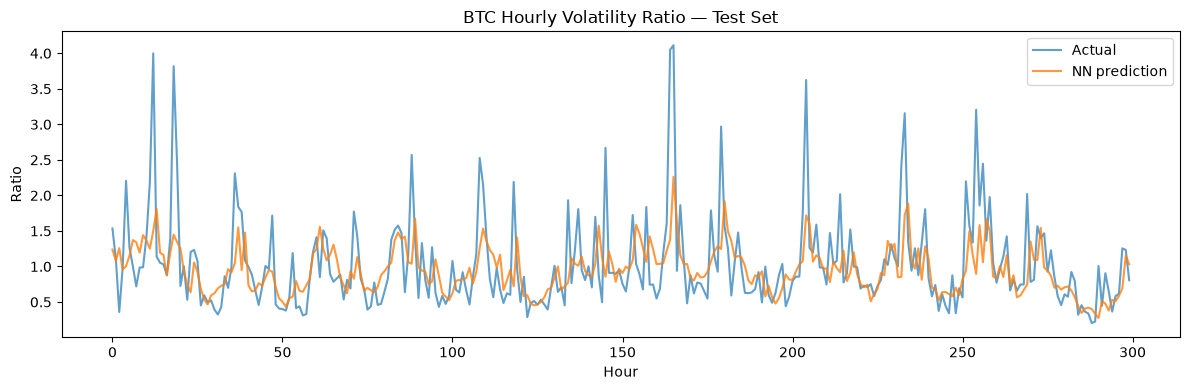

In [41]:
n = 300 

plt.figure(figsize=(12, 4))
plt.plot(y_test[:n], label="Actual", alpha=0.7)
plt.plot(preds[:n], label="NN prediction", alpha=0.8)
plt.title("BTC Hourly Volatility Ratio — Test Set")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
split_point = int(len(df_clean) * 0.8)

x = df_clean[feature_cols].values.astype("float32")
y = df_clean["target"].values.astype("float32")

x_train = x[:split_point]
x_test = x[split_point:]

y_train = y[:split_point]
y_test = y[split_point:]

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = xgb.XGBRegressor(
     n_estimators=100,    
    max_depth=5,           
    learning_rate=0.1,    
    objective='reg:squarederror',
    random_state=42,
)

model.fit(
    x_train,y_train,
    eval_set=[(x_test, y_test)],
    verbose = False
)

xgb_predict = model.predict(x_test)

mse = mean_squared_error(y_test, xgb_predict)
mae = mean_absolute_error(y_test, xgb_predict)
r2 = r2_score(y_test, xgb_predict)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score (Variance Explained): {r2:.4f}")


Mean Absolute Error (MAE): 0.4167
Mean Squared Error (MSE): 0.4353
R² Score (Variance Explained): 0.1909


In [44]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

split_point = int(len(df_clean) * 0.8)

x = df_clean[feature_cols].values.astype("float32")
y = df_clean["target"].values.astype("float32")

x_train = x[:split_point]
x_test = x[split_point:]

y_train = y[:split_point]
y_test = y[split_point:]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

ridge_model  = Ridge(alpha=1.0)
ridge_model.fit(x_train_scaled, y_train)

y_pred = ridge_model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print("Model Coefficients:", ridge_model.coef_)
print("Mean Squared Error:", mse)

ridge_pred = ridge_model.predict(x_test_scaled)

print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))
print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))
print("Ridge R²:", r2_score(y_test, ridge_pred))


Model Coefficients: [ 0.01073491 -0.02194519 -0.03272898 -0.00823218  0.1271549  -0.14057326
  0.11657543 -0.00308115  0.16641593 -0.14351282 -0.01982941 -0.00037423
 -0.04549801 -0.03646746  0.00822408  0.01867912 -0.01643284  0.00033304
  0.00283136  0.00120004  0.00154131  0.00815291 -0.12899499  0.13630831
 -0.01718928  0.04287997 -0.0007254   0.00094146 -0.09633845  0.10008383
 -0.00259596 -0.06866502 -0.00208047  0.01365123  0.00870943 -0.02392361
  0.00611202  0.02456751  0.06821093  0.00043414 -0.00317231  0.03278066
  0.00361718 -0.00493767  0.0002081  -0.00167354 -0.03552128  0.00722557
 -0.00077812  0.00431511]
Mean Squared Error: 0.44049063324928284
Ridge MAE: 0.41595086455345154
Ridge MSE: 0.44049063324928284
Ridge R²: 0.18119019269943237


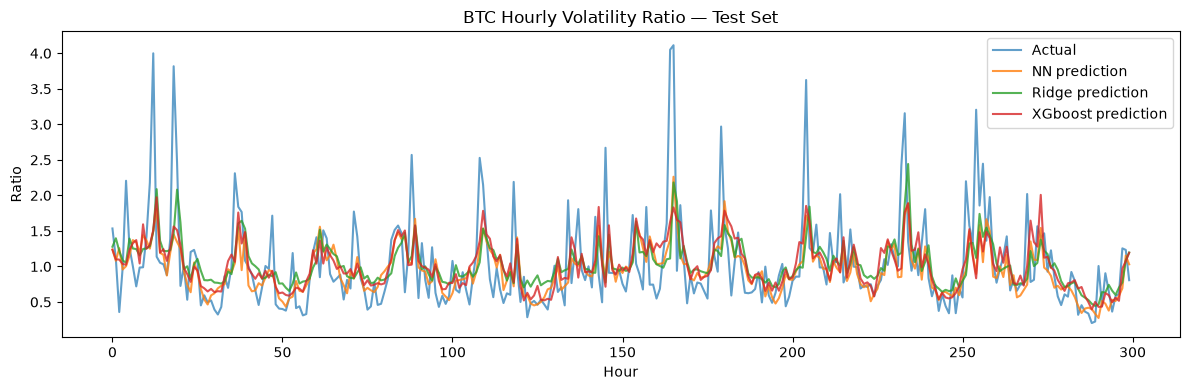

In [45]:
n = 300 

plt.figure(figsize=(12, 4))
plt.plot(y_test[:n], label="Actual", alpha=0.7)
plt.plot(preds[:n], label="NN prediction", alpha=0.8)
plt.plot(ridge_pred[:n], label = "Ridge prediction" , alpha=0.8)
plt.plot(xgb_predict[:n],label = "XGboost prediction",alpha = 0.8)
plt.title("BTC Hourly Volatility Ratio — Test Set")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

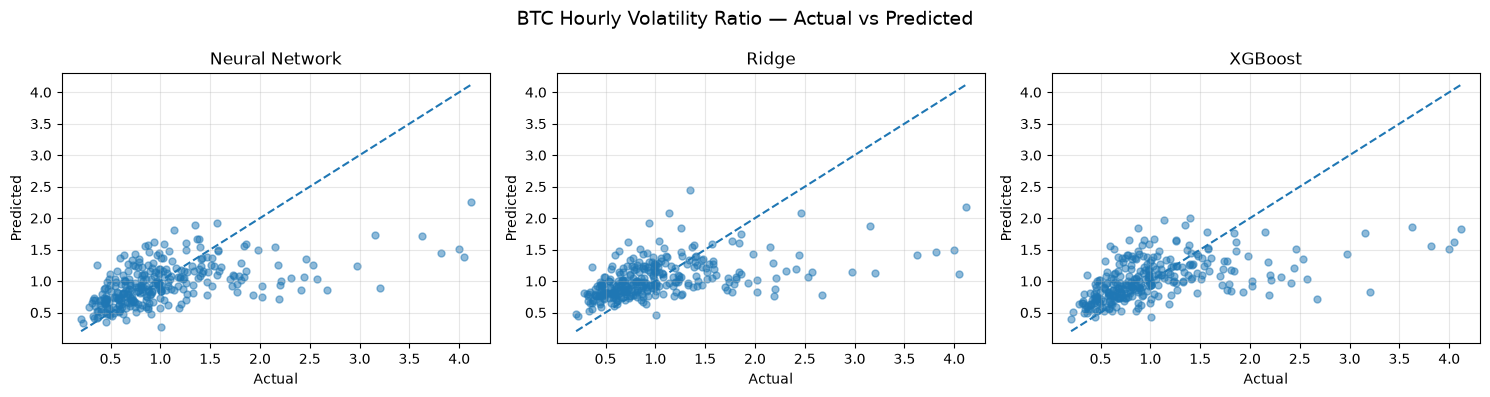

In [46]:
n = 300

actual = np.asarray(y_test[:n]).ravel()
nn = np.asarray(preds[:n]).ravel()
ridge = np.asarray(ridge_pred[:n]).ravel()
xgb = np.asarray(xgb_predict[:n]).ravel()

all_values = np.concatenate([actual, nn, ridge, xgb])
min_value = all_values.min()
max_value = all_values.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [
    ("Neural Network", nn),
    ("Ridge", ridge),
    ("XGBoost", xgb)
]

for ax, (name, prediction) in zip(axes, models):
    ax.scatter(actual, prediction, alpha=0.5, s=25)
    ax.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.3)

fig.suptitle("BTC Hourly Volatility Ratio — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()
